# CodeAlpha_HandwrittenCharacterRecognition
### Task 3: Handwritten Character Recognition — CNN

Recognizing handwritten digits (0-9) using a Convolutional Neural Network trained on the MNIST dataset (42,000 labeled 28x28 grayscale images).

**Steps:**
1. Import libraries
2. Load dataset
3. Explore the data
4. Preprocess (reshape, normalize, one-hot encode)
5. Train/test split
6. Build the CNN
7. Train the model
8. Evaluate (accuracy, classification report, confusion matrix)
9. Visualize predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")
%matplotlib inline
print("TensorFlow version:", tf.__version__)

I0000 00:00:1784493036.581239     579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784493036.676179     579 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784493038.547264     579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## 1. Load the Dataset

In [2]:
df = pd.read_csv("mnist.csv")
print("Shape:", df.shape)
df.head()

Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Explore the Data

In [3]:
df['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

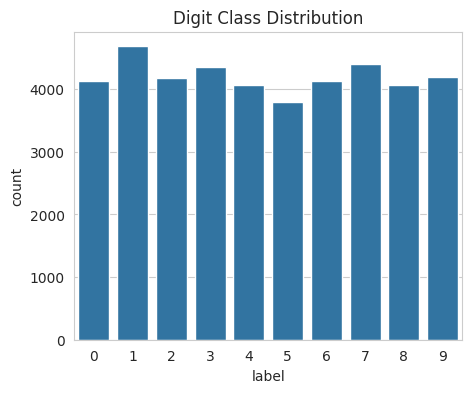

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title("Digit Class Distribution")
plt.show()

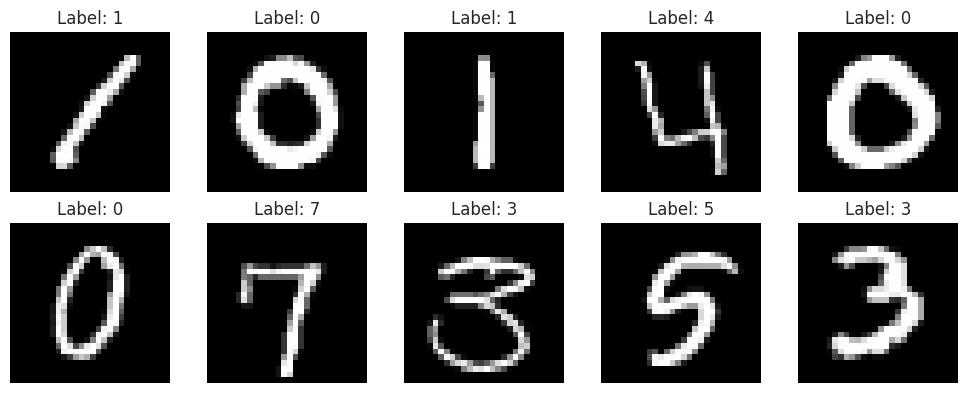

In [5]:
# Visualize a few sample digits
X_raw = df.drop('label', axis=1).values
y_raw = df['label'].values

fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_raw[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y_raw[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Preprocess the Data

In [6]:
# Normalize pixel values to [0, 1] and reshape for CNN input (28x28x1)
X = X_raw.astype('float32') / 255.0
X = X.reshape(-1, 28, 28, 1)

# One-hot encode labels
y = to_categorical(y_raw, num_classes=10)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (42000, 28, 28, 1)
y shape: (42000, 10)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_raw
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (33600, 28, 28, 1)
Test shape : (8400, 28, 28, 1)


## 4. Build the CNN

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    verbose=2
)

Epoch 1/8


237/237 - 8s - 35ms/step - accuracy: 0.8832 - loss: 0.3784 - val_accuracy: 0.9679 - val_loss: 0.1004


Epoch 2/8


237/237 - 10s - 42ms/step - accuracy: 0.9678 - loss: 0.1026 - val_accuracy: 0.9792 - val_loss: 0.0704


Epoch 3/8


...

237/237 - 11s - 44ms/step - accuracy: 0.9866 - loss: 0.0406 - val_accuracy: 0.9851 - val_loss: 0.0477


Epoch 7/8


237/237 - 10s - 41ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9860 - val_loss: 0.0417


Epoch 8/8


237/237 - 10s - 43ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9875 - val_loss: 0.0376


## 6. Training Curves

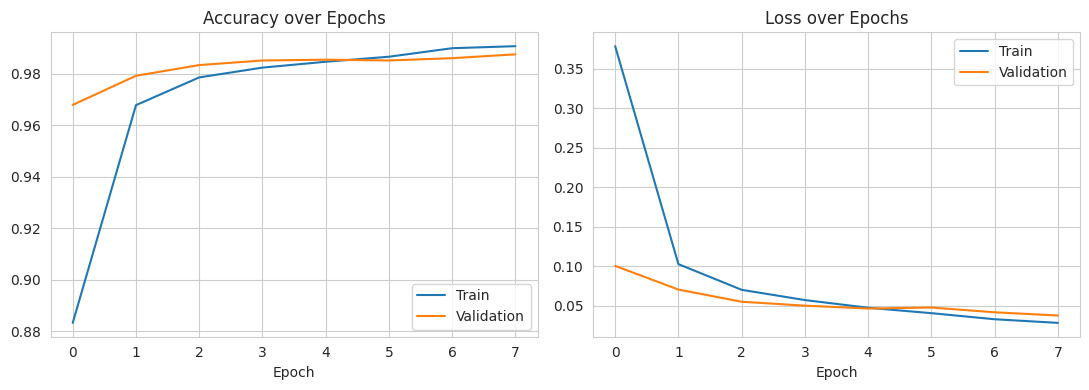

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on Test Set

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")

Test Accuracy: 0.9877
Test Loss    : 0.0408


In [12]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       827
           1       0.99      1.00      0.99       937
           2       0.99      0.98      0.98       835
           3       0.99      0.98      0.99       870
           4       0.99      0.99      0.99       814
           5       0.99      0.98      0.98       759
           6       0.98      1.00      0.99       827
           7       0.99      0.99      0.99       880
           8       0.98      0.98      0.98       813
           9       0.98      0.98      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



## 8. Confusion Matrix

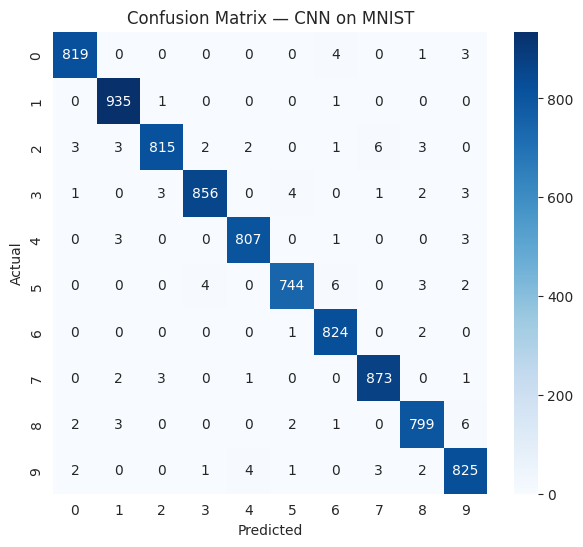

In [13]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — CNN on MNIST")
plt.show()

## 9. Visualize Predictions

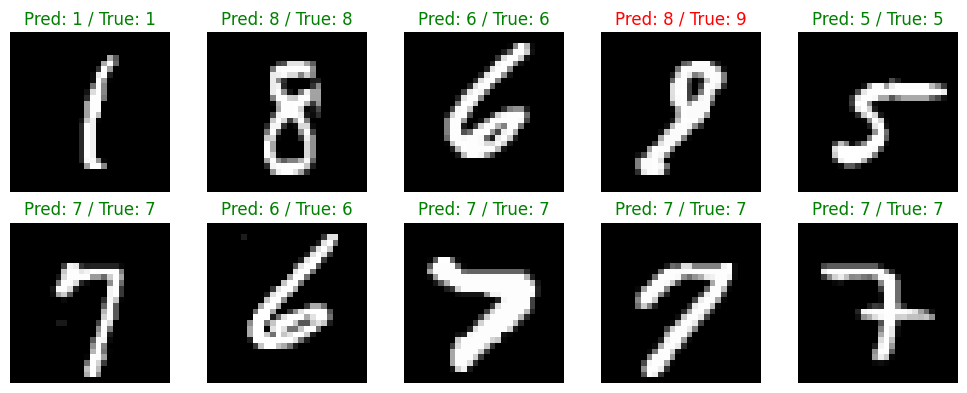

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    ax.set_title(f"Pred: {y_pred[i]} / True: {y_true[i]}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 10. Conclusion

- Built a **CNN** (2 convolutional blocks + dense layers) to classify handwritten digits from the MNIST dataset.
- Achieved strong test accuracy after only 8 training epochs.
- Confusion matrix shows most misclassifications occur between visually similar digits (e.g. 4 vs 9, 3 vs 8).

**Possible extensions:** train on EMNIST for full alphabet character recognition, add data augmentation (rotation/shift) for robustness, or extend to a CRNN for full word/sentence recognition as suggested in the task brief.